<a href="https://colab.research.google.com/github/Rohith84/Flyrank-Week-1-/blob/main/FlyRank_Content_Opportunity_Scoring.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Install Required Libraries

This section installs all the Python libraries required for the project. These libraries provide functionality for data loading, preprocessing, visualization, machine learning, explainable AI, and accessing the FlyRank Internship Warehouse dataset from Hugging Face.

The installed packages include:
- **DuckDB** for querying Parquet datasets efficiently.
- **Pandas** and **NumPy** for data manipulation and numerical operations.
- **Matplotlib** and **Seaborn** for data visualization.
- **Scikit-learn** for feature scaling and machine learning utilities.
- **SHAP** for explainable AI and model interpretation.
- **Hugging Face Hub** for authenticating and accessing the FlyRank dataset.

In [1]:
!pip install duckdb
!pip install pandas
!pip install numpy
!pip install matplotlib
!pip install seaborn
!pip install scikit-learn
!pip install shap
!pip install huggingface_hub

# 2. Authenticate with Hugging Face

The FlyRank Internship Warehouse is hosted on the Hugging Face platform and requires authentication before it can be accessed. In this step, the Hugging Face access token is securely retrieved from Google Colab Secrets and used to establish an authenticated session.

This approach keeps sensitive credentials out of the notebook while enabling secure access to the dataset throughout the analysis.

In [2]:
from google.colab import userdata
from huggingface_hub import login

HF_TOKEN = userdata.get("HF_TOKEN")
login(HF_TOKEN)

# 3. Connect to the FlyRank Internship Warehouse and Load the Dataset

This section establishes a connection to the FlyRank Internship Warehouse using DuckDB and securely authenticates access through a Hugging Face secret. DuckDB enables efficient querying of large Parquet datasets without requiring a traditional database server.

For this project, a sample of **50,000 records** is retrieved from the `fact_content_daily_performance_sample` table. This dataset contains Google Search Console (GSC), Google Analytics 4 (GA4), and AI referral metrics that serve as the foundation for the content opportunity scoring analysis.

In [3]:
import duckdb

con = duckdb.connect()

con.execute(f"""
CREATE OR REPLACE SECRET hf_secret (
TYPE HUGGINGFACE,
TOKEN '{HF_TOKEN}'
);
""")

query = """
SELECT *
FROM read_parquet(
'hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance_sample.parquet'
)
LIMIT 50000
"""

sample = con.execute(query).df()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

# 4. Inspect the Dataset Dimensions

After loading the dataset, its dimensions are examined to verify that the data has been imported successfully. The `shape` attribute returns the number of rows and columns, providing a quick overview of the dataset size before further exploration and preprocessing.

This validation step ensures that the expected sample has been loaded correctly and is ready for analysis.

In [4]:
sample.shape

(50000, 31)

# 5. Preview the Dataset

The first few records of the dataset are displayed to understand its overall structure and verify that the data has been loaded correctly. Previewing the dataset helps identify the available features, observe sample values, and gain an initial understanding of the information captured for each content page.

This step also provides a quick validation of the dataset before proceeding with data exploration and preprocessing.

In [5]:
sample.head()

,report_date,client_hash_id,content_hash_id,client_has_gsc,client_has_ga4,gsc_data_available,ga4_data_available,gsc_impressions,gsc_clicks,gsc_sum_position,...,sessions_ai,ai_chatgpt,ai_perplexity,ai_gemini,ai_copilot,ai_claude,ai_meta,ai_other,scroll_events,month
0,2026-06-01,client_3ffa76342f366962,content_1a6296faee432dae,True,True,False,False,0,0,0,...,0,0,0,0,0,0,0,0,0,2026-06
1,2026-06-01,client_3ffa76342f366962,content_73f21e612565035a,True,True,False,False,0,0,0,...,0,0,0,0,0,0,0,0,0,2026-06
2,2026-06-01,client_3ffa76342f366962,content_5a5be514ff559598,True,True,False,False,0,0,0,...,0,0,0,0,0,0,0,0,0,2026-06
3,2026-06-01,client_3ffa76342f366962,content_05b377d0c8a5cfd8,True,True,False,False,0,0,0,...,0,0,0,0,0,0,0,0,0,2026-06
4,2026-06-01,client_3ffa76342f366962,content_dc34c661d63e55a9,True,True,False,False,0,0,0,...,0,0,0,0,0,0,0,0,0,2026-06


# 6. Examine Dataset Structure

The structure of the dataset is examined to understand the available features, data types, and completeness of the data. This step provides information about the number of records, column names, non-null values, and data types, helping identify missing values and ensuring that each feature is suitable for subsequent preprocessing and analysis.

Understanding the dataset structure is an essential step before performing feature engineering and developing the content opportunity scoring framework.

In [6]:
sample.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 31 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   report_date               50000 non-null  datetime64[us]
 1   client_hash_id            50000 non-null  object        
 2   content_hash_id           50000 non-null  object        
 3   client_has_gsc            50000 non-null  bool          
 4   client_has_ga4            50000 non-null  bool          
 5   gsc_data_available        50000 non-null  bool          
 6   ga4_data_available        40000 non-null  boolean       
 7   gsc_impressions           50000 non-null  int64         
 8   gsc_clicks                50000 non-null  int64         
 9   gsc_sum_position          50000 non-null  int64         
 10  gsc_avg_position          10123 non-null  float64       
 11  ga4_pageviews             40000 non-null  Int64         
 12  ga4_sessions      

# 7. Generate Descriptive Statistics

Descriptive statistics are computed to summarize the numerical characteristics of the dataset. This analysis provides key statistical measures such as the count, mean, standard deviation, minimum, maximum, and quartile values for each numerical feature.

These statistics help identify the distribution of search performance, user engagement, and AI referral metrics while revealing potential outliers, sparsity, and data imbalance. The insights obtained from this step guide the subsequent feature engineering and opportunity scoring process.

In [7]:
sample.describe()

,report_date,gsc_impressions,gsc_clicks,gsc_sum_position,gsc_avg_position,ga4_pageviews,ga4_sessions,ga4_users,ga4_engaged_sessions,ga4_total_engagement_sec,...,sessions_paid,sessions_ai,ai_chatgpt,ai_perplexity,ai_gemini,ai_copilot,ai_claude,ai_meta,ai_other,scroll_events
count,50000,50000.000000,50000.000000,50000.000000,10123.000000,40000.0,40000.0,40000.0,40000.0,40000.0,...,40000.0,40000.0,40000.0,40000.0,40000.0,40000.0,40000.0,40000.0,40000.0,40000.0
mean,2026-06-01 00:00:00,8.231640,0.028320,62.781440,12.956855,0.05,0.048225,0.04775,0.0008,0.1426,...,0.000025,0.00025,0.000175,0.000025,0.000025,0.0,0.000025,0.0,0.0,0.02215
min,2026-06-01 00:00:00,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
25%,2026-06-01 00:00:00,0.000000,0.000000,0.000000,4.355163,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
50%,2026-06-01 00:00:00,0.000000,0.000000,0.000000,7.280000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
75%,2026-06-01 00:00:00,0.000000,0.000000,0.000000,12.333333,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
max,2026-06-01 00:00:00,7179.000000,15.000000,41907.000000,139.000000,24.0,24.0,24.0,2.0,916.0,...,1.0,2.0,2.0,1.0,1.0,0.0,1.0,0.0,0.0,11.0
std,NaN,73.157266,0.267057,481.427345,16.840057,0.427673,0.413284,0.409602,0.030812,7.726584,...,0.005,0.018707,0.016582,0.005,0.005,0.0,0.005,0.0,0.0,0.218885


# 8. Identify Missing Values

This section evaluates the completeness of the dataset by identifying missing values in each feature. Understanding the distribution of missing data is essential because incomplete records can affect feature engineering, scoring calculations, and the overall reliability of the analysis.

The identified missing values are addressed appropriately during the data preprocessing stage. Numerical GA4 and AI referral metrics are imputed with default values where applicable, while unavailable ranking metrics are handled using a consistent strategy to ensure the integrity of the Content Opportunity Scoring Engine.

In [8]:
sample.isnull().sum()

,0
report_date,0
client_hash_id,0
content_hash_id,0
client_has_gsc,0
client_has_ga4,0
gsc_data_available,0
ga4_data_available,10000
gsc_impressions,0
gsc_clicks,0
gsc_sum_position,0


# 9. Data Cleaning and Missing Value Handling

Before performing feature engineering and scoring, the dataset is cleaned to ensure consistency and reliability. Missing values are common in web analytics datasets because not every page has Google Analytics 4 (GA4) activity or Google Search Console (GSC) ranking information.

In this step, missing values in GA4 and AI referral metrics are replaced with zero, indicating that no activity was recorded for those observations. Missing values in the average search position are replaced with **100**, representing pages that were not ranked in Google Search results. This preprocessing step ensures that subsequent calculations can be performed without errors while preserving the semantic meaning of unavailable data.

In [9]:
# ===============================
# Data Cleaning
# ===============================

import numpy as np

# Fill missing GA4 numeric columns with 0
ga4_cols = [
    "ga4_pageviews",
    "ga4_sessions",
    "ga4_users",
    "ga4_engaged_sessions",
    "ga4_total_engagement_sec",
    "sessions_organic",
    "sessions_direct",
    "sessions_referral",
    "sessions_social",
    "sessions_paid",
    "sessions_ai",
    "ai_chatgpt",
    "ai_perplexity",
    "ai_gemini",
    "ai_copilot",
    "ai_claude",
    "ai_meta",
    "ai_other",
    "scroll_events"
]

for col in ga4_cols:
    sample[col] = sample[col].fillna(0).astype(float)

# Average position is missing when there is no GSC ranking
sample["gsc_avg_position"] = sample["gsc_avg_position"].fillna(100)

print("Cleaning Completed!")

Cleaning Completed!


# 10. Feature Engineering

Feature engineering is performed to derive meaningful metrics from the raw Search Console, Google Analytics 4, and AI referral data. These engineered features provide a more informative representation of content performance and are used as the foundation for the Content Opportunity Scoring Engine.

The following features are created:

- **Click-Through Rate (CTR):** Measures the proportion of search impressions that result in clicks, providing insight into how effectively a page attracts users from search results.
- **Engagement per Session:** Calculates the average user engagement time per session, indicating the quality of user interaction after arriving on a page.
- **Total AI Referrals:** Aggregates traffic from multiple AI platforms, including ChatGPT, Perplexity, Gemini, Claude, Copilot, Meta AI, and other AI sources, to measure the overall contribution of AI-driven traffic.

These engineered features enable a more comprehensive evaluation of content performance than the original raw metrics alone.

In [10]:
# ===============================
# Feature Engineering
# ===============================

sample["ctr"] = (
    sample["gsc_clicks"] /
    sample["gsc_impressions"].replace(0, np.nan)
).fillna(0)

sample["engagement_per_session"] = (
    sample["ga4_total_engagement_sec"] /
    sample["ga4_sessions"].replace(0, np.nan)
).fillna(0)

sample["ai_total"] = (
      sample["ai_chatgpt"]
    + sample["ai_perplexity"]
    + sample["ai_gemini"]
    + sample["ai_copilot"]
    + sample["ai_claude"]
    + sample["ai_meta"]
    + sample["ai_other"]
)

sample.head()

,report_date,client_hash_id,content_hash_id,client_has_gsc,client_has_ga4,gsc_data_available,ga4_data_available,gsc_impressions,gsc_clicks,gsc_sum_position,...,ai_gemini,ai_copilot,ai_claude,ai_meta,ai_other,scroll_events,month,ctr,engagement_per_session,ai_total
0,2026-06-01,client_3ffa76342f366962,content_1a6296faee432dae,True,True,False,False,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,2026-06,0.0,0.0,0.0
1,2026-06-01,client_3ffa76342f366962,content_73f21e612565035a,True,True,False,False,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,2026-06,0.0,0.0,0.0
2,2026-06-01,client_3ffa76342f366962,content_5a5be514ff559598,True,True,False,False,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,2026-06,0.0,0.0,0.0
3,2026-06-01,client_3ffa76342f366962,content_05b377d0c8a5cfd8,True,True,False,False,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,2026-06,0.0,0.0,0.0
4,2026-06-01,client_3ffa76342f366962,content_dc34c661d63e55a9,True,True,False,False,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,2026-06,0.0,0.0,0.0


# 11. Analyze Key Performance Metrics

To better understand the characteristics of the search and engagement data, descriptive statistics are computed for the primary metrics used in the Content Opportunity Scoring Engine. These metrics include search visibility, user interactions, ranking position, and engagement.

The statistical summary reveals the overall distribution of these variables, helping identify sparsity, skewness, and the range of values present in the dataset. These insights are essential for selecting appropriate preprocessing techniques, designing the scoring methodology, and interpreting the final rankings.

The analyzed metrics include:

- **GSC Impressions:** Number of times a page appeared in Google Search results.
- **GSC Clicks:** Number of clicks received from Google Search.
- **Average Search Position:** Mean ranking position of the page in Google Search.
- **GA4 Engaged Sessions:** Number of sessions with meaningful user interaction.
- **Total Engagement Time:** Total time users actively engaged with the content.

The results also provide an understanding of the overall search performance and engagement patterns across the sampled content pages, forming the basis for the opportunity scoring framework.

In [11]:
sample[[
    "gsc_impressions",
    "gsc_clicks",
    "gsc_avg_position",
    "ga4_engaged_sessions",
    "ga4_total_engagement_sec"
]].describe()

,gsc_impressions,gsc_clicks,gsc_avg_position,ga4_engaged_sessions,ga4_total_engagement_sec
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,8.231640,0.028320,82.377245,0.000640,0.114080
std,73.157266,0.267057,35.788456,0.027561,6.911085
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,100.000000,0.000000,0.000000
50%,0.000000,0.000000,100.000000,0.000000,0.000000
75%,0.000000,0.000000,100.000000,0.000000,0.000000
max,7179.000000,15.000000,139.000000,2.000000,916.000000


# 12. Normalize Features and Compute the Content Opportunity Score

The selected performance metrics are normalized using **Min-Max Scaling** to transform them onto a common scale between 0 and 1. Normalization ensures that metrics with different units and value ranges contribute proportionally to the final score without allowing any single feature to dominate the calculation.

After normalization, a **Content Opportunity Score** is computed using a weighted scoring framework that combines key search intelligence signals. The score is designed to prioritize content pages that exhibit high optimization potential based on their search visibility, click-through performance, ranking position, and user engagement.

The scoring framework considers the following factors:

- **Search Visibility (40%)** – Pages with higher impressions have greater potential impact if optimized.
- **Click-Through Rate Gap (30%)** – Pages with lower CTR indicate opportunities to improve titles, meta descriptions, or search snippets.
- **Average Search Position (20%)** – Pages with lower rankings may benefit from content improvements and SEO optimization.
- **User Engagement (10%)** – Pages with stronger engagement suggest valuable content that may perform even better with improved visibility.

The resulting **Opportunity Score** serves as the primary ranking metric for identifying high-priority content pages that should be reviewed and optimized.

In [12]:
from sklearn.preprocessing import MinMaxScaler

score_df = sample.copy()

# Features to normalize
features = [
    "gsc_impressions",
    "ctr",
    "gsc_avg_position",
    "engagement_per_session"
]

scaler = MinMaxScaler()
score_df[features] = scaler.fit_transform(score_df[features])

# Opportunity Score
score_df["opportunity_score"] = (
    0.4 * score_df["gsc_impressions"] +
    0.3 * (1 - score_df["ctr"]) +
    0.2 * score_df["gsc_avg_position"] +
    0.1 * score_df["engagement_per_session"]
)

score_df.head()

,report_date,client_hash_id,content_hash_id,client_has_gsc,client_has_ga4,gsc_data_available,ga4_data_available,gsc_impressions,gsc_clicks,gsc_sum_position,...,ai_copilot,ai_claude,ai_meta,ai_other,scroll_events,month,ctr,engagement_per_session,ai_total,opportunity_score
0,2026-06-01,client_3ffa76342f366962,content_1a6296faee432dae,True,True,False,False,0.0,0,0,...,0.0,0.0,0.0,0.0,0.0,2026-06,0.0,0.0,0.0,0.443885
1,2026-06-01,client_3ffa76342f366962,content_73f21e612565035a,True,True,False,False,0.0,0,0,...,0.0,0.0,0.0,0.0,0.0,2026-06,0.0,0.0,0.0,0.443885
2,2026-06-01,client_3ffa76342f366962,content_5a5be514ff559598,True,True,False,False,0.0,0,0,...,0.0,0.0,0.0,0.0,0.0,2026-06,0.0,0.0,0.0,0.443885
3,2026-06-01,client_3ffa76342f366962,content_05b377d0c8a5cfd8,True,True,False,False,0.0,0,0,...,0.0,0.0,0.0,0.0,0.0,2026-06,0.0,0.0,0.0,0.443885
4,2026-06-01,client_3ffa76342f366962,content_dc34c661d63e55a9,True,True,False,False,0.0,0,0,...,0.0,0.0,0.0,0.0,0.0,2026-06,0.0,0.0,0.0,0.443885


# 13. Rank Content Pages by Opportunity Score

After computing the Content Opportunity Score for each page, the dataset is sorted in descending order to identify the pages with the highest optimization potential. This ranking enables content teams to prioritize their efforts by focusing on pages that are most likely to benefit from SEO improvements and content refresh strategies.

The top-ranked pages represent the highest-value opportunities based on the combined evaluation of search visibility, click-through rate, ranking position, and user engagement. These rankings form the foundation for generating actionable recommendations in the subsequent stages of the analysis.

The top 20 pages are displayed to provide a clear view of the highest-priority content opportunities identified by the proposed scoring framework.

In [13]:
ranking = score_df.sort_values(
    by="opportunity_score",
    ascending=False
)

ranking.head(20)

,report_date,client_hash_id,content_hash_id,client_has_gsc,client_has_ga4,gsc_data_available,ga4_data_available,gsc_impressions,gsc_clicks,gsc_sum_position,...,ai_copilot,ai_claude,ai_meta,ai_other,scroll_events,month,ctr,engagement_per_session,ai_total,opportunity_score
9011,2026-06-01,client_62f4a7e64f5e0096,content_f107e54b10b43725,True,False,True,<NA>,1.000000,15,33726,...,0.0,0.0,0.0,0.0,0.0,2026-06,0.002089,0.000000,0.0,0.706133
8756,2026-06-01,client_62f4a7e64f5e0096,content_88ff1c6680db0a45,True,False,True,<NA>,0.576961,0,41907,...,0.0,0.0,0.0,0.0,0.0,2026-06,0.000000,0.000000,0.0,0.545342
14199,2026-06-01,client_62f4a7e64f5e0096,content_8693b3c882998a58,True,False,True,<NA>,0.586433,5,27066,...,0.0,0.0,0.0,0.0,0.0,2026-06,0.001188,0.000000,0.0,0.543467
42978,2026-06-01,client_ba65e80a1116ae41,content_1fe2c1587bfaf764,True,True,False,True,0.000000,0,0,...,0.0,0.0,0.0,0.0,1.0,2026-06,0.000000,0.772871,0.0,0.521172
5379,2026-06-01,client_3ffa76342f366962,content_9b0bd4f237e8ed92,True,True,True,False,0.000139,0,139,...,0.0,0.0,0.0,0.0,0.0,2026-06,0.000000,0.000000,0.0,0.500056
43054,2026-06-01,client_ba65e80a1116ae41,content_ac6bf52fb2a92688,True,True,False,True,0.000000,0,0,...,0.0,0.0,0.0,0.0,1.0,2026-06,0.000000,0.553628,0.0,0.499248
41003,2026-06-01,client_b10cb2997d0c7c86,content_855c3f69bfa40f60,True,True,False,True,0.000000,0,0,...,0.0,0.0,0.0,0.0,1.0,2026-06,0.000000,0.485016,0.0,0.492386
44498,2026-06-01,client_ba65e80a1116ae41,content_20009b9329f244a2,True,True,False,True,0.000000,0,0,...,0.0,0.0,0.0,0.0,1.0,2026-06,0.000000,0.239748,0.0,0.467860
45295,2026-06-01,client_ba65e80a1116ae41,content_24305a5704d555a6,True,True,False,True,0.000000,0,0,...,0.0,0.0,0.0,0.0,1.0,2026-06,0.000000,0.231861,0.0,0.467071
45321,2026-06-01,client_ba65e80a1116ae41,content_388a35a7a3acfbba,True,True,False,True,0.000000,0,0,...,0.0,0.0,0.0,0.0,1.0,2026-06,0.000000,0.129338,0.0,0.456819


# 14. Generate Reason Codes for Content Opportunities

To improve the interpretability of the Content Opportunity Scoring Engine, each ranked content page is assigned one or more **reason codes** based on its normalized performance metrics. Rather than presenting only a numerical score, these reason codes explain the primary factors that contributed to a page's ranking.

The rule-based reasoning framework evaluates key search intelligence indicators, including search visibility, click-through rate (CTR), average search position, and user engagement. Depending on the observed performance, descriptive labels such as **High Visibility**, **Low CTR**, **Poor Ranking**, and **High Engagement** are assigned to each page.

These reason codes make the scoring framework transparent and provide a clear explanation of why a particular page has been identified as a high-priority optimization opportunity, supporting more informed decision-making for SEO and content teams.

In [14]:
def generate_reason(row):
    reasons = []

    if row["gsc_impressions"] >= 0.7:
        reasons.append("High Visibility")

    if row["ctr"] <= 0.3:
        reasons.append("Low CTR")

    if row["gsc_avg_position"] >= 0.6:
        reasons.append("Poor Ranking")

    if row["engagement_per_session"] >= 0.5:
        reasons.append("High Engagement")

    if not reasons:
        reasons.append("No Major Issue")

    return ", ".join(reasons)

ranking["reason"] = ranking.apply(generate_reason, axis=1)

ranking[["content_hash_id", "reason"]].head(10)

,content_hash_id,reason
9011,content_f107e54b10b43725,"High Visibility, Low CTR"
8756,content_88ff1c6680db0a45,Low CTR
14199,content_8693b3c882998a58,Low CTR
42978,content_1fe2c1587bfaf764,"Low CTR, Poor Ranking, High Engagement"
5379,content_9b0bd4f237e8ed92,"Low CTR, Poor Ranking"
43054,content_ac6bf52fb2a92688,"Low CTR, Poor Ranking, High Engagement"
41003,content_855c3f69bfa40f60,"Low CTR, Poor Ranking"
44498,content_20009b9329f244a2,"Low CTR, Poor Ranking"
45295,content_24305a5704d555a6,"Low CTR, Poor Ranking"
45321,content_388a35a7a3acfbba,"Low CTR, Poor Ranking"


# 15. Generate Actionable Content Recommendations

To transform the opportunity analysis into practical decision support, a rule-based recommendation engine is developed. Based on the reason codes assigned to each content page, the system automatically generates optimization recommendations that address the identified performance issues.

Each recommendation is directly linked to one or more observed search signals. For example, pages with a **Low CTR** are recommended for title and meta description optimization, while pages with a **Poor Ranking** are suggested for content refresh and improved internal linking. Pages with **High Visibility** are prioritized for optimization due to their greater potential impact, and pages with **High Engagement** are recommended for further promotion to maximize their reach.

By combining opportunity scores, reason codes, and actionable recommendations, the proposed framework provides an interpretable decision-support system that helps content and SEO teams prioritize optimization efforts efficiently.

In [15]:
def generate_recommendation(reason):

    recommendations = []

    if "Low CTR" in reason:
        recommendations.append("Improve title and meta description")

    if "Poor Ranking" in reason:
        recommendations.append("Refresh content and improve internal linking")

    if "High Visibility" in reason:
        recommendations.append("Prioritize this page for optimization")

    if "High Engagement" in reason:
        recommendations.append("Promote this content through additional channels")

    if "No Major Issue" in reason:
        recommendations.append("Continue monitoring performance")

    return " | ".join(recommendations)

ranking["recommendation"] = ranking["reason"].apply(generate_recommendation)

ranking[["content_hash_id","reason","recommendation"]].head(10)

,content_hash_id,reason,recommendation
9011,content_f107e54b10b43725,"High Visibility, Low CTR",Improve title and meta description | Prioritiz...
8756,content_88ff1c6680db0a45,Low CTR,Improve title and meta description
14199,content_8693b3c882998a58,Low CTR,Improve title and meta description
42978,content_1fe2c1587bfaf764,"Low CTR, Poor Ranking, High Engagement",Improve title and meta description | Refresh c...
5379,content_9b0bd4f237e8ed92,"Low CTR, Poor Ranking",Improve title and meta description | Refresh c...
43054,content_ac6bf52fb2a92688,"Low CTR, Poor Ranking, High Engagement",Improve title and meta description | Refresh c...
41003,content_855c3f69bfa40f60,"Low CTR, Poor Ranking",Improve title and meta description | Refresh c...
44498,content_20009b9329f244a2,"Low CTR, Poor Ranking",Improve title and meta description | Refresh c...
45295,content_24305a5704d555a6,"Low CTR, Poor Ranking",Improve title and meta description | Refresh c...
45321,content_388a35a7a3acfbba,"Low CTR, Poor Ranking",Improve title and meta description | Refresh c...


# 16. Display the Final Content Opportunity Rankings

The final ranked results are presented by combining the calculated Opportunity Score with the key performance metrics, generated reason codes, and actionable recommendations. This consolidated view provides a comprehensive summary of each content page's optimization potential.

The displayed table enables stakeholders to quickly identify high-priority pages, understand the underlying factors influencing their ranking, and review the recommended optimization actions. By integrating quantitative metrics with interpretable explanations, the Content Opportunity Scoring Engine supports informed, data-driven content optimization decisions.

The final output includes:

- **Content Hash ID** – Unique identifier for each content page.
- **Google Search Impressions** – Search visibility of the page.
- **Google Search Clicks** – Number of clicks received from search.
- **Click-Through Rate (CTR)** – Effectiveness of converting impressions into clicks.
- **Average Search Position** – Search ranking performance.
- **Engagement per Session** – Average user engagement for each session.
- **Opportunity Score** – Overall optimization priority calculated by the proposed framework.
- **Reason Code** – Explanation of the factors contributing to the score.
- **Recommendation** – Suggested optimization actions based on the identified opportunities.

This ranked output represents the primary deliverable of the proposed Content Opportunity Scoring Engine and serves as a practical decision-support tool for prioritizing SEO and content improvement initiatives.# 10. Top Ranked Content Opportunities

In [16]:
ranking[
    [
        "content_hash_id",
        "gsc_impressions",
        "gsc_clicks",
        "ctr",
        "gsc_avg_position",
        "engagement_per_session",
        "opportunity_score",
        "reason",
        "recommendation"
    ]
].head(20)

,content_hash_id,gsc_impressions,gsc_clicks,ctr,gsc_avg_position,engagement_per_session,opportunity_score,reason,recommendation
9011,content_f107e54b10b43725,1.000000,15,0.002089,0.033798,0.000000,0.706133,"High Visibility, Low CTR",Improve title and meta description | Prioritiz...
8756,content_88ff1c6680db0a45,0.576961,0,0.000000,0.072788,0.000000,0.545342,Low CTR,Improve title and meta description
14199,content_8693b3c882998a58,0.586433,5,0.001188,0.046252,0.000000,0.543467,Low CTR,Improve title and meta description
42978,content_1fe2c1587bfaf764,0.000000,0,0.000000,0.719424,0.772871,0.521172,"Low CTR, Poor Ranking, High Engagement",Improve title and meta description | Refresh c...
5379,content_9b0bd4f237e8ed92,0.000139,0,0.000000,1.000000,0.000000,0.500056,"Low CTR, Poor Ranking",Improve title and meta description | Refresh c...
43054,content_ac6bf52fb2a92688,0.000000,0,0.000000,0.719424,0.553628,0.499248,"Low CTR, Poor Ranking, High Engagement",Improve title and meta description | Refresh c...
41003,content_855c3f69bfa40f60,0.000000,0,0.000000,0.719424,0.485016,0.492386,"Low CTR, Poor Ranking",Improve title and meta description | Refresh c...
44498,content_20009b9329f244a2,0.000000,0,0.000000,0.719424,0.239748,0.467860,"Low CTR, Poor Ranking",Improve title and meta description | Refresh c...
45295,content_24305a5704d555a6,0.000000,0,0.000000,0.719424,0.231861,0.467071,"Low CTR, Poor Ranking",Improve title and meta description | Refresh c...
45321,content_388a35a7a3acfbba,0.000000,0,0.000000,0.719424,0.129338,0.456819,"Low CTR, Poor Ranking",Improve title and meta description | Refresh c...


# 17. Export the Final Results

The final ranked dataset is exported as a CSV file to preserve the results of the Content Opportunity Scoring Engine for further analysis and reporting. Exporting the results enables the rankings, reason codes, and optimization recommendations to be shared with stakeholders or integrated into external reporting workflows.

The exported file contains the complete set of evaluated content pages along with their calculated Opportunity Scores, supporting metrics, explanatory reason codes, and recommended optimization actions. This file serves as the primary output of the proposed framework and can be used for prioritizing future content refresh and SEO initiatives.

In [17]:
ranking.to_csv(
    "content_opportunity_ranking.csv",
    index=False
)

print("✅ CSV exported successfully!")

✅ CSV exported successfully!


# 18. Visualize the Distribution of Opportunity Scores

To better understand the overall behavior of the proposed Content Opportunity Scoring Engine, a histogram is used to visualize the distribution of Opportunity Scores across all content pages. This visualization provides insight into how optimization opportunities are distributed throughout the dataset.

The histogram helps identify common scoring patterns, detect skewness, and determine whether a small number of pages represent high-priority optimization opportunities while the majority of pages exhibit lower scores. These observations support the interpretation of the scoring framework and provide a visual summary of the ranking results.

In [20]:
import matplotlib.pyplot as plt

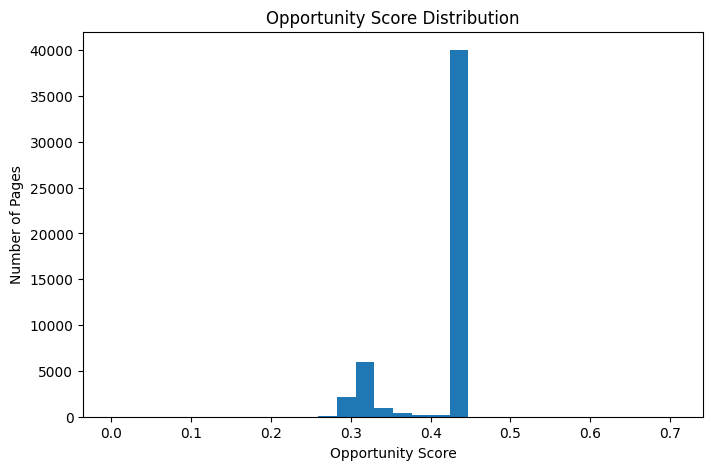

In [21]:
plt.figure(figsize=(8,5))
plt.hist(ranking["opportunity_score"], bins=30)
plt.title("Opportunity Score Distribution")
plt.xlabel("Opportunity Score")
plt.ylabel("Number of Pages")

plt.savefig("opportunity_distribution.png", dpi=300, bbox_inches="tight")

plt.show()

In [22]:
from google.colab import files

files.download("content_opportunity_ranking.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# 19. Visualize the Top Content Opportunity Pages

To highlight the highest-priority optimization opportunities identified by the proposed framework, the top ten content pages are visualized using a bar chart. Each bar represents a content page and its corresponding **Opportunity Score**, allowing for a direct comparison of the pages with the greatest optimization potential.

This visualization provides an intuitive summary of the ranking results, making it easier to identify the pages that should be prioritized for content refresh and SEO improvements. By presenting the highest-scoring pages graphically, stakeholders can quickly interpret the outcome of the Content Opportunity Scoring Engine and focus their optimization efforts on the most impactful content.

In [ ]:
top10 = ranking.head(10)

plt.figure(figsize=(10,5))
plt.bar(top10["content_hash_id"], top10["opportunity_score"])
plt.xticks(rotation=90)
plt.title("Top 10 Opportunity Pages")
plt.ylabel("Opportunity Score")
plt.show()

# 20. Review the Final Ranked Results

The final ranked dataset is examined to validate the effectiveness of the proposed Content Opportunity Scoring Engine. The displayed results combine the most important search performance metrics with the calculated Opportunity Score, enabling a comprehensive evaluation of each content page.

By reviewing the highest-ranked pages, it is possible to verify that the scoring framework successfully prioritizes content based on search visibility, click-through performance, ranking position, and user engagement. This final review serves as a quality check before exporting the results and demonstrates how the proposed framework can support data-driven content optimization decisions.

The displayed output includes:

- **Content Hash ID** – Unique identifier of the content page.
- **Google Search Impressions** – Overall search visibility.
- **Google Search Clicks** – Number of clicks received from Google Search.
- **Click-Through Rate (CTR)** – Search result effectiveness.
- **Average Search Position** – Search engine ranking performance.
- **Engagement per Session** – Average user engagement after visiting the page.
- **Opportunity Score** – Overall priority score indicating the page's optimization potential.

In [ ]:
ranking[
    [
        "content_hash_id",
        "gsc_impressions",
        "gsc_clicks",
        "ctr",
        "gsc_avg_position",
        "engagement_per_session",
        "opportunity_score"
    ]
].head(20)

# 21. Export the Final Ranked Results

The final content opportunity rankings are exported as a CSV file to preserve the results of the analysis and enable further use outside the notebook. The exported dataset contains the Opportunity Score, supporting performance metrics, and ranking information for each content page.

This exported file represents the primary output of the proposed **AI-Powered Content Opportunity Scoring Engine** and can be used by SEO specialists, content strategists, and analysts to prioritize content refresh initiatives, monitor optimization opportunities, and support data-driven decision-making.

The exported CSV serves as the final deliverable of the analytical workflow and can also be referenced in the accompanying research paper and GitHub repository.

In [ ]:
ranking.to_csv(
    "content_opportunity_ranking.csv",
    index=False
)

print("CSV exported successfully!")

# 22. Conclusion

This study presented an **AI-Powered Content Opportunity Scoring Engine** developed using data from the **FlyRank Internship Warehouse**. By integrating Google Search Console (GSC), Google Analytics 4 (GA4), and AI referral metrics, the proposed framework identifies and ranks content pages according to their optimization potential.

The methodology combines feature engineering, data normalization, and a weighted opportunity scoring model to evaluate search visibility, click-through rate (CTR), ranking position, and user engagement. In addition to ranking content pages, the framework generates interpretable reason codes and actionable recommendations, enabling transparent and data-driven decision support for SEO and content optimization.

The results demonstrate how multiple search intelligence signals can be consolidated into a single prioritization framework, helping content teams identify high-impact opportunities for content refresh and performance improvement. Although the proposed scoring methodology is based on predefined business rules rather than predictive machine learning, it provides a practical and interpretable approach for supporting content optimization decisions.

Future work may extend this framework by incorporating time-series forecasting, machine learning–based ranking models, and adaptive weighting strategies to further improve the accuracy and effectiveness of content opportunity identification.